In [43]:
import os

# List all folders under /kaggle/input
print(os.listdir("/kaggle/input"))

['data']


In [54]:

/# Example to list images or CSVs
print(os.listdir("/kaggle/input/data"))

['images_003', 'images_012', 'LOG_CHESTXRAY.pdf', 'README_CHESTXRAY.pdf', 'BBox_List_2017.csv', 'images_009', 'images_008', 'images_007', 'test_list.txt', 'images_010', 'ARXIV_V5_CHESTXRAY.pdf', 'images_002', 'images_011', 'Data_Entry_2017.csv', 'images_001', 'train_val_list.txt', 'images_005', 'FAQ_CHESTXRAY.pdf', 'images_004', 'images_006']


In [55]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt # plotting
import numpy as np # linear algebra

import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [56]:
nRowsRead = 1000 # specify 'None' if want to read whole file
df1 = pd.read_csv('/kaggle/input/data/BBox_List_2017.csv', delimiter=',', nrows = nRowsRead)
df1.dataframeName = 'BBox_List_2017.csv'
nRow, nCol = df1.shape
print(f'There are {nRow} rows and {nCol} columns')

There are 984 rows and 9 columns


In [57]:
# Distribution graphs (histogram/bar graph) of column data
def plotPerColumnDistribution(df, nGraphShown, nGraphPerRow):
    nunique = df.nunique()
    df = df[[col for col in df if nunique[col] > 1 and nunique[col] < 50]] # For displaying purposes, pick columns that have between 1 and 50 unique values
    nRow, nCol = df.shape
    columnNames = list(df)
    # Ensure nGraphRow is an integer using floor division (//)
    nGraphRow = (nCol + nGraphPerRow - 1) // nGraphPerRow
    plt.figure(num = None, figsize = (6 * nGraphPerRow, 8 * nGraphRow), dpi = 80, facecolor = 'w', edgecolor = 'k')
    for i in range(min(nCol, nGraphShown)):
        plt.subplot(nGraphRow, nGraphPerRow, i + 1)
        columnDf = df.iloc[:, i]
        if (not np.issubdtype(type(columnDf.iloc[0]), np.number)):
            valueCounts = columnDf.value_counts()
            valueCounts.plot.bar()
        else:
            columnDf.hist()
        plt.ylabel('counts')
        plt.xticks(rotation = 90)
        plt.title(f'{columnNames[i]} (column {i})')
    plt.tight_layout(pad = 1.0, w_pad = 1.0, h_pad = 1.0)
    plt.show()

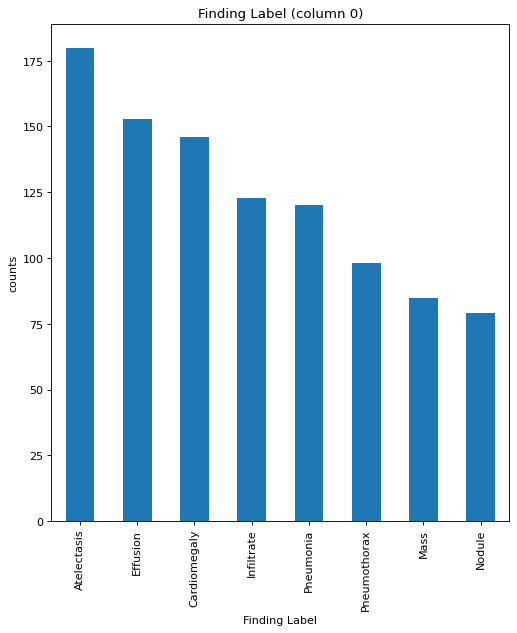

In [58]:
plotPerColumnDistribution(df1, 10, 5)


In [60]:
# Correlation matrix
def plotCorrelationMatrix(df, graphWidth):
    filename = df.dataframeName
    # Use axis=1 for columns (equivalent to 'columns' in older versions)
    df = df.dropna(axis=1)  # drop columns with NaN
    # Select only numeric columns
    df = df.select_dtypes(include=np.number)
    df = df[[col for col in df if df[col].nunique() > 1]] # keep columns where there are more than 1 unique values
    if df.shape[1] < 2:
        print(f'No correlation plots shown: The number of non-NaN or constant columns ({df.shape[1]}) is less than 2')
        return
    corr = df.corr()
    # Create a new figure instead of reusing fignum=1
    fig, ax = plt.subplots(figsize=(graphWidth, graphWidth), dpi=80, facecolor='w', edgecolor='k')

    # Use ax.matshow instead of plt.matshow
    corrMat = ax.matshow(corr)

    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.gca().xaxis.tick_bottom()
    plt.colorbar(corrMat)
    plt.title(f'Correlation Matrix for {filename}', fontsize=15)
    plt.show()

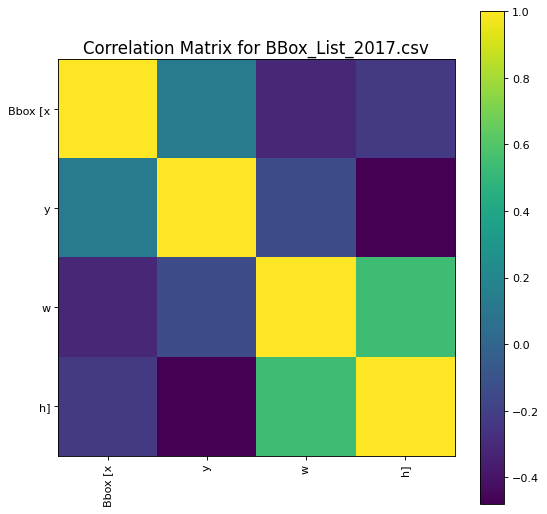

In [61]:
plotCorrelationMatrix(df1, 8)


In [63]:
def plotScatterMatrix(df, plotSize, textSize):
    df = df.select_dtypes(include =[np.number]) # keep only numerical columns
    # Remove rows and columns that would lead to df being singular
    df = df.dropna(axis='columns') # Changed 'columns' to axis='columns'
    df = df[[col for col in df if df[col].nunique() > 1]] # keep columns where there are more than 1 unique values
    columnNames = list(df)
    if len(columnNames) > 10: # reduce the number of columns for matrix inversion of kernel density plots
        columnNames = columnNames[:10]
    df = df[columnNames]
    ax = pd.plotting.scatter_matrix(df, alpha=0.75, figsize=[plotSize, plotSize], diagonal='kde')
    corrs = df.corr().values
    for i, j in zip(*plt.np.triu_indices_from(ax, k = 1)):
        ax[i, j].annotate('Corr. coef = %.3f' % corrs[i, j], (0.8, 0.2), xycoords='axes fraction', ha='center', va='center', size=textSize)
    plt.suptitle('Scatter and Density Plot')
    plt.show()

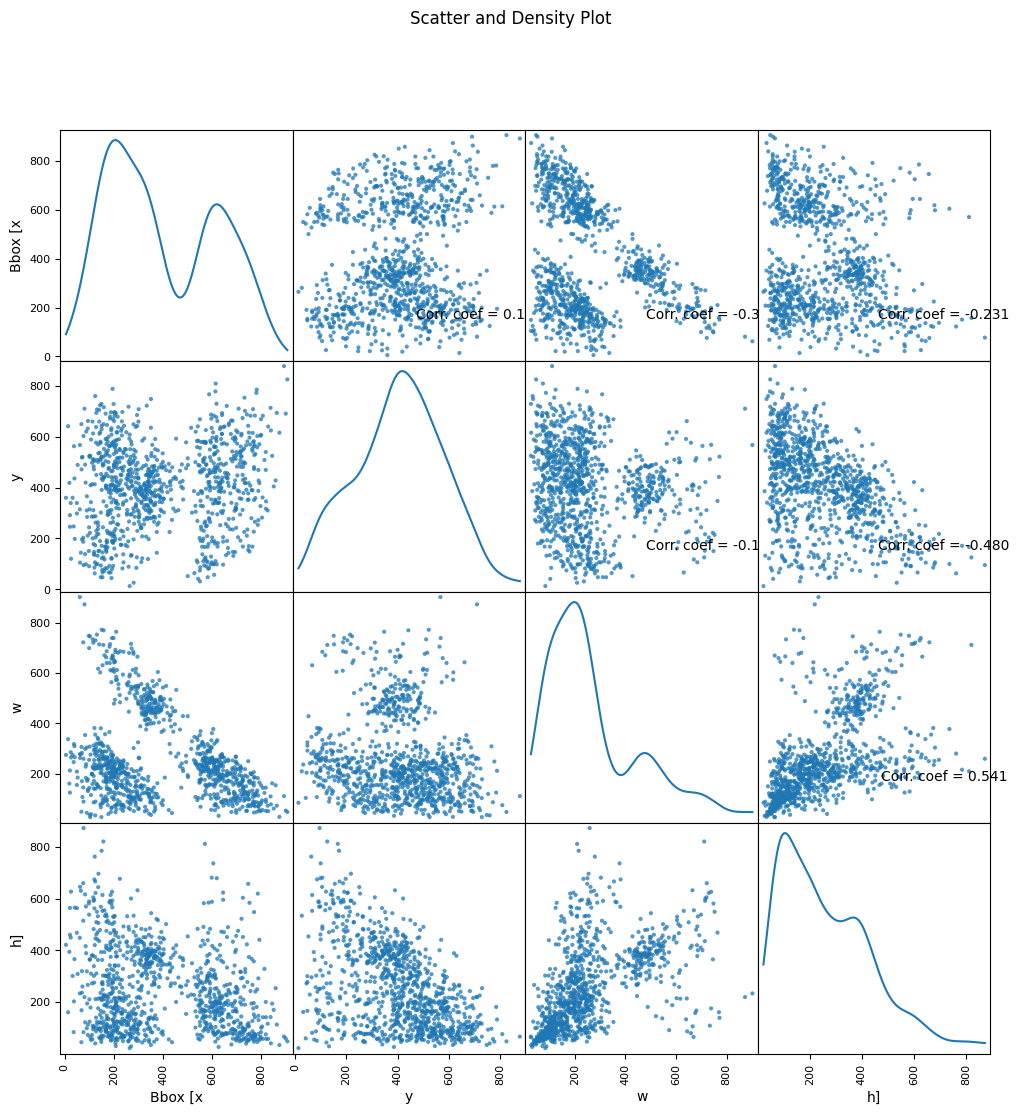

In [64]:
plotScatterMatrix(df1, 12, 10)


In [66]:
import os
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, random_split

# ✅ Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ✅ Load CSV and prepare labels
df = pd.read_csv('/kaggle/input/data/Data_Entry_2017.csv')
df = df[['Image Index', 'Finding Labels']]

# Multi-label setup
all_labels = ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass',
              'Nodule', 'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema',
              'Emphysema', 'Fibrosis', 'Pleural_Thickening', 'Hernia']

for label in all_labels:
    df[label] = df['Finding Labels'].apply(lambda x: 1 if label in x else 0)

# ✅ Map images from subdirectories
image_root_dir = "/kaggle/input/data"
image_map = {}

for root, dirs, files in os.walk(image_root_dir):
    for file in files:
        if file.endswith(('.png', '.jpg', '.jpeg')):
            image_map[file] = os.path.join(root, file)

# ✅ Filter available images only
df = df[df['Image Index'].isin(image_map)].copy()

# ✅ Use a subset for faster training
subset_df = df.iloc[:1000].copy()

# ✅ Image transformations
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # RGB normalization
])

# ✅ Custom Dataset class
class ChestXrayDataset(Dataset):
    def __init__(self, df, image_map, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_map = image_map
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.loc[idx, 'Image Index']
        img_path = self.image_map[img_name]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        labels = self.df.loc[idx, all_labels].values.astype('float32')
        return image, torch.tensor(labels)

# ✅ Prepare dataset and dataloaders
dataset = ChestXrayDataset(subset_df, image_map, transform)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset, [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

# ✅ Model definition
def create_model():
    return nn.Sequential(
        nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        nn.Flatten(),
        nn.Linear(64 * 16 * 16, 128), nn.ReLU(),
        nn.Linear(128, len(all_labels)), nn.Sigmoid()  # Multi-label output
    )

model = create_model().to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ✅ Training loop
epochs = 5
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

# ✅ Inference function
def predict_diseases(model, image_path, transform, threshold=0.5):
    model.eval()
    image = Image.open(image_path).convert('RGB')
    image = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image)[0].cpu().numpy()

    predicted = [all_labels[i] for i, val in enumerate(output) if val > threshold]

    print("\n--- Prediction Result ---")
    if predicted:
        print("Diseases detected:")
        for disease in predicted:
            print(f" - {disease}")
    else:
        print("No disease detected.")

# ✅ Example usage (only after training)
# predict_diseases(model, "/kaggle/input/data/images00000001.png", transform)


Using device: cpu
Epoch [1/5], Loss: 0.2832
Epoch [2/5], Loss: 0.2263
Epoch [3/5], Loss: 0.2197
Epoch [4/5], Loss: 0.2124
Epoch [5/5], Loss: 0.2064


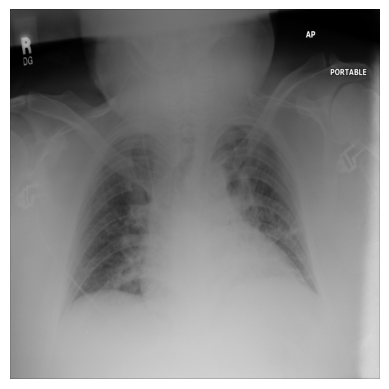

Prediction: ❌ No Disease


In [67]:
import matplotlib.pyplot as plt

def predict_single_image(image_path, model, transform, threshold=0.5):
    model.eval()
    image = Image.open(image_path).convert('RGB')

    # Display the image
    plt.imshow(image)
    plt.axis('off')  # Hide axes for cleaner look
    plt.show()

    # Transform the image and make prediction
    image_transformed = transform(image).unsqueeze(0).to(device)
    output = model(image_transformed)  # output has 14 elements (for each disease)

    # Detach the output from the computation graph and convert it to numpy
    preds = (output.detach().squeeze().cpu().numpy() > threshold).astype(int)  # Detach here

    # Get diseases detected
    detected_diseases = [all_labels[i] for i in range(len(all_labels)) if preds[i] == 1]

    if detected_diseases:
        prediction = "✅ Disease Detected: " + ", ".join(detected_diseases)
    else:
        prediction = "❌ No Disease"

    return prediction

# Example
test_image_path = '/kaggle/input/data/images_006/images/00011558_008.png'  # use a valid image path
prediction = predict_single_image(test_image_path, model, transform)
print("Prediction:", prediction)

In [69]:
!git config --global user.email "psamirbirthy@gmail.com"
!git config --global user.name "SAMIXhub"

In [70]:
!git clone https://github.com/SAMIXhub/AIBasedMedicalDiagnosis.git


Cloning into 'AIBasedMedicalDiagnosis'...
fatal: unable to access 'https://github.com/SAMIXhub/AIBasedMedicalDiagnosis.git/': Could not resolve host: github.com
